### Ex 10.1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

im1 = cv2.imread('im1.jpg')
im2 = cv2.imread('im2.jpg')

gray1 = cv2.cvtColor(im1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(im2, cv2.COLOR_BGR2GRAY)

sift = cv2.SIFT_create()
kp1, des1 = sift.detectAndCompute(gray1, None)
kp2, des2 = sift.detectAndCompute(gray2, None)

# Cross-check: only keep pairs that are mutual nearest neighbours
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
matches = bf.match(des1, des2)
matches = sorted(matches, key=lambda m: m.distance)

print(len(kp1), len(kp2), len(matches))

8223 6060 2410


In [2]:
pts1 = np.array([kp1[m.queryIdx].pt for m in matches]).T   # (2, n)
pts2 = np.array([kp2[m.trainIdx].pt for m in matches]).T   # (2, n)

(np.float64(-0.5), np.float64(1499.5), np.float64(999.5), np.float64(-0.5))

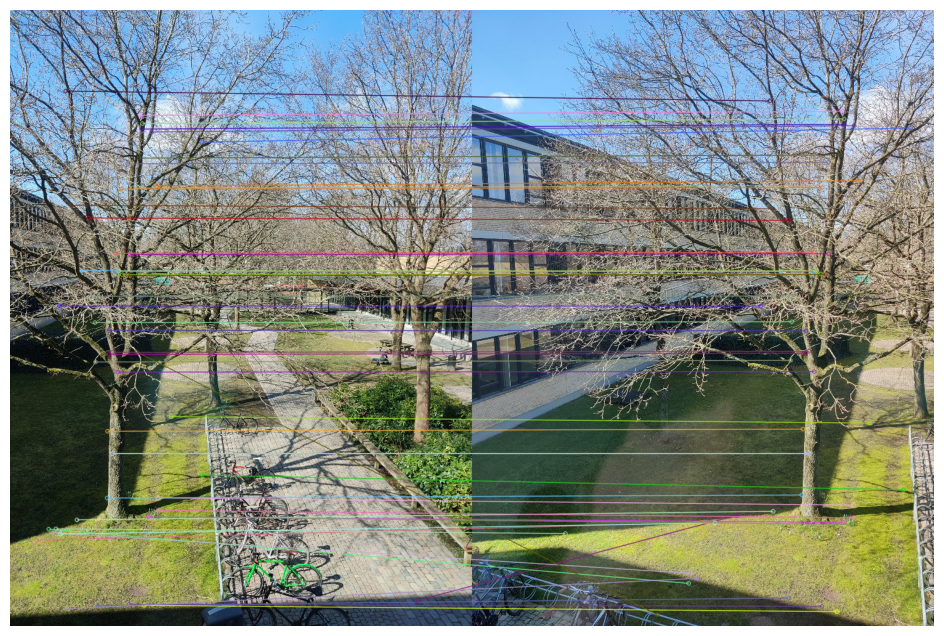

In [3]:
out = cv2.drawMatches(im1, kp1, im2, kp2, matches[:50], None,
                      flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize=(15, 8))
plt.imshow(out[:, :, ::-1])
plt.axis('off')

### Ex 10.2